In [18]:
# ============================================================
# GeoAI + UNet (ResNet34, ImageNet) label-efficiency experiment
# Fractions: {10, 20, 30, 50, 100} of the train set
# Adds model complexity stats per fraction.
# ============================================================

import os, time, glob, shutil, random
from pathlib import Path
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import torch

import geoai
import segmentation_models_pytorch as smp  # used for param counts (same arch/encoder)

# ----------------------- setup & download -----------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

URL = "https://huggingface.co/datasets/giswqs/geospatial/resolve/main/waterbody-dataset.zip"
BASE = Path(geoai.download_file(URL))  # e.g., ".../waterbody-dataset"
print("Dataset root:", BASE)

IMG_DIR = BASE / "images"
MSK_DIR = BASE / "masks"
assert IMG_DIR.exists() and MSK_DIR.exists(), "images/ or masks/ folder missing."

Using device: cuda
File already exists: waterbody-dataset.zip
Dataset root: waterbody-dataset


In [19]:
# ----------------------- utility helpers -----------------------
def list_files(folder, exts=("jpg","jpeg","png","tif","tiff")):
    files=[]
    for e in exts: files += glob.glob(str(Path(folder)/f"*.{e}"))
    return sorted(files)

def _bin_mask(path):
    # prediction/gt may be {0,1} or {0,255}; make 0/1
    a = np.array(Image.open(path).convert("L"), dtype=np.uint8)
    return (a >= 128).astype(np.uint8)
    return sorted(files)

def pair_images_masks(img_dir, msk_dir):
    imgs = list_files(img_dir)
    mask_map = {Path(p).stem: p for p in list_files(msk_dir)}
    pairs = [(i, mask_map[Path(i).stem]) for i in imgs if Path(i).stem in mask_map]
    return pairs

def safe_copy(src, dst):
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

def write_pairs(pairs, out_img_dir, out_msk_dir):
    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_msk_dir.mkdir(parents=True, exist_ok=True)
    for ip, mp in pairs:
        safe_copy(ip, out_img_dir/Path(ip).name)
        safe_copy(mp, out_msk_dir/Path(mp).name)

def load_mask_binary(path):
    # masks are 0/255 jpg/png; convert to {0,1}
    m = Image.open(path).convert("L")
    a = np.array(m, dtype=np.uint8)
    return (a >= 128).astype(np.uint8)

def overall_acc(pred, gt):
    return float((pred == gt).sum() / gt.size)

def iou_binary(pred, gt):
    inter = np.logical_and(pred==1, gt==1).sum()
    union = np.logical_or (pred==1, gt==1).sum()
    return float(inter / max(1, union))

def dice_binary(pred, gt):
    inter = np.logical_and(pred==1, gt==1).sum()
    return float((2*inter) / max(1, (pred==1).sum() + (gt==1).sum()))

def evaluate_folder(gt_dir, pred_dir, verbose=True):
    """Match GT 'water_body_XXXX' with predictions that may be named
       'water_body_XXXX.png' or 'water_body_XXXX_mask.png' (GeoAI default)."""
    gt_paths   = list_files(gt_dir)
    pred_paths = list_files(pred_dir)

    pred_map = {}
    for p in pred_paths:
        stem = Path(p).stem
        pred_map[stem] = p
        # also register without the trailing '_mask'
        if stem.endswith("_mask"):
            pred_map[stem[:-5]] = p

    n_pairs = 0
    oa_list, iou_list, dice_list = [], [], []
    for g in gt_paths:
        key = Path(g).stem
        if key not in pred_map:
            continue
        gt = _bin_mask(g)
        pr = _bin_mask(pred_map[key])
        n_pairs += 1
        # metrics
        oa   = (pr == gt).mean()
        inter = np.logical_and(pr==1, gt==1).sum()
        union = np.logical_or (pr==1, gt==1).sum()
        iou  = inter / max(1, union)
        dice = (2*inter) / max(1, (pr==1).sum() + (gt==1).sum())
        oa_list.append(oa); iou_list.append(iou); dice_list.append(dice)

    if verbose:
        print(f"[eval] matched {n_pairs}/{len(gt_paths)} files in {pred_dir}")

    if n_pairs == 0:
        return float("nan"), float("nan"), float("nan")
    return float(np.mean(oa_list)), float(np.mean(iou_list)), float(np.mean(dice_list))

In [20]:
# ----------------------- fixed split (80/10/10) -----------------------
ALL = pair_images_masks(IMG_DIR, MSK_DIR)
assert len(ALL) > 0, "No image/mask pairs found."
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(ALL))
ALL = [ALL[i] for i in perm]

n = len(ALL)
n_tr = int(round(0.8*n))
n_va = int(round(0.1*n))
train_pairs = ALL[:n_tr]
val_pairs   = ALL[n_tr:n_tr+n_va]
test_pairs  = ALL[n_tr+n_va:]

SPLIT_DIR = BASE / "fixed_split"
(TR_IMG, TR_MSK) = (SPLIT_DIR/"train_images", SPLIT_DIR/"train_masks")
(VA_IMG, VA_MSK) = (SPLIT_DIR/"val_images",   SPLIT_DIR/"val_masks")
(TE_IMG, TE_MSK) = (SPLIT_DIR/"test_images",  SPLIT_DIR/"test_masks")

# write (idempotent)
if not TR_IMG.exists():
    write_pairs(train_pairs, TR_IMG, TR_MSK)
    write_pairs(val_pairs,   VA_IMG, VA_MSK)
    write_pairs(test_pairs,  TE_IMG, TE_MSK)

print(f"Split sizes -> train:{len(list_files(TR_IMG))}  val:{len(list_files(VA_IMG))}  test:{len(list_files(TE_IMG))}")

Split sizes -> train:2273  val:284  test:284


In [21]:
# ----------------------- build fraction subsets -----------------------
FRACTIONS = [10, 20, 30, 50, 100]  # percent
FR_BASE = BASE / "fractions"
FR_BASE.mkdir(exist_ok=True)

train_img_set = list_files(TR_IMG)
train_msk_map = {Path(p).stem: p for p in list_files(TR_MSK)}

for pct in FRACTIONS:
    out_i = FR_BASE / f"frac_{pct}" / "images"
    out_m = FR_BASE / f"frac_{pct}" / "masks"
    if out_i.exists() and len(list_files(out_i))>0:
        continue
    k = max(1, int(round(len(train_img_set)*pct/100.0)))
    sel = rng.choice(train_img_set, size=k, replace=False)
    pairs = [(p, train_msk_map[Path(p).stem]) for p in sel if Path(p).stem in train_msk_map]
    write_pairs(pairs, out_i, out_m)
    print(f"Prepared fraction {pct}% -> {len(pairs)} images")

In [22]:
# ----------------------- constants (model/training) -----------------------
ARCH       = "unet"
ENCODER    = "resnet34"
ENC_WTS    = "imagenet"
IMG_SZ     = (512, 512)
EPOCHS     = 10
BATCH_SIZE = 16

# ----------------------- helpers: model stats -----------------------
def build_unet_resnet34(in_ch=3, classes=2):
    # same arch as geoai.train_segmentation_model call
    return smp.Unet(encoder_name=ENCODER, encoder_weights=ENC_WTS,
                    in_channels=in_ch, classes=classes)

def count_params(model):
    t = sum(p.numel() for p in model.parameters())
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return int(t), int(tr)

# ----------------------- training & evaluation loop -----------------------
results = []

for pct in FRACTIONS:
    print(f"\n=== Fraction {pct}% ===")
    frac_img = FR_BASE / f"frac_{pct}" / "images"
    frac_msk = FR_BASE / f"frac_{pct}" / "masks"
    n_sub    = len(list_files(frac_img))
    print(f"Training subset size: {n_sub}")

    # ---- model complexity (param counts) from SMP UNet config
    tmp_model = build_unet_resnet34(3, 2)
    params_total, params_trainable = count_params(tmp_model)
    del tmp_model

    # ---- GeoAI requires a non-zero val_split to checkpoint "best model"
    internal_val_split = max(1.0 / max(1,n_sub), 0.004)  # at least ~1 image
    print(f"Internal val_split used: {internal_val_split:.4f}")

    out_models = BASE / f"unet_resnet34_frac_{pct}_models"
    out_models.mkdir(parents=True, exist_ok=True)

    # ---- Train
    t0 = time.time()
    geoai.train_segmentation_model(
        images_dir=str(frac_img),
        labels_dir=str(frac_msk),
        output_dir=str(out_models),
        architecture=ARCH,
        encoder_name=ENCODER,
        encoder_weights=ENC_WTS,
        num_channels=3,
        num_classes=2,
        batch_size=BATCH_SIZE,
        num_epochs=EPOCHS,
        learning_rate=1e-3,
        val_split=internal_val_split,    # <<< key (must be > 0)
        target_size=IMG_SZ,
        seed=SEED,
        verbose=True,
    )
    train_time = time.time() - t0
    best_model = out_models / "best_model.pth"

    # ---- Model size (saved weights on disk)
    try:
        model_size_MB = os.path.getsize(best_model) / (1024*1024)
    except FileNotFoundError:
        model_size_MB = float("nan")

    # ---- Predict on fixed external VAL (not timed)
    val_pred_dir = BASE / f"pred_val_frac_{pct}"
    val_pred_dir.mkdir(exist_ok=True)
    geoai.semantic_segmentation_batch(
        input_dir=str(VA_IMG),
        output_dir=str(val_pred_dir),
        model_path=str(best_model),
        architecture=ARCH,
        encoder_name=ENCODER,
        num_channels=3,
        num_classes=2,
        window_size=IMG_SZ[0],
        overlap=IMG_SZ[0]//2,
        batch_size=32,
        quiet=True,
    )
    val_OA, val_IoU, val_Dice = evaluate_folder(VA_MSK, val_pred_dir)

    # ---- Predict on fixed external TEST (timed to get ms/img)
    test_pred_dir = BASE / f"pred_test_frac_{pct}"
    test_pred_dir.mkdir(exist_ok=True)
    n_test_imgs = len(list_files(TE_IMG))
    t1 = time.time()
    geoai.semantic_segmentation_batch(
        input_dir=str(TE_IMG),
        output_dir=str(test_pred_dir),
        model_path=str(best_model),
        architecture=ARCH,
        encoder_name=ENCODER,
        num_channels=3,
        num_classes=2,
        window_size=IMG_SZ[0],
        overlap=IMG_SZ[0]//2,
        batch_size=32,
        quiet=True,
    )
    infer_time_s = time.time() - t1
    infer_ms_per_img = (infer_time_s / max(1,n_test_imgs)) * 1000.0

    test_OA, test_IoU, test_Dice = evaluate_folder(TE_MSK, test_pred_dir)

    row = dict(
        fraction_pct=pct,
        n_train_imgs=n_sub,
        params_total=params_total,
        params_trainable=params_trainable,
        model_size_MB=round(model_size_MB,3),
        train_time_s=round(train_time,3),
        infer_ms_per_img=round(infer_ms_per_img,3),
        val_OA=round(val_OA,4),   val_IoU=round(val_IoU,4),   val_Dice=round(val_Dice,4),
        test_OA=round(test_OA,4), test_IoU=round(test_IoU,4), test_Dice=round(test_Dice,4),
        ckpt=str(best_model),
    )
    results.append(row)
    print(f"VAL  -> OA:{row['val_OA']:.4f} | IoU:{row['val_IoU']:.4f} | Dice:{row['val_Dice']:.4f}")
    print(f"TEST -> OA:{row['test_OA']:.4f} | IoU:{row['test_IoU']:.4f} | Dice:{row['test_Dice']:.4f}")
    print(f"Model params: total={params_total:,} | trainable={params_trainable:,} | size={model_size_MB:.2f} MB")
    print(f"Train time: {train_time:.1f}s | Inference: {infer_ms_per_img:.1f} ms/img")


=== Fraction 10% ===
Training subset size: 227
Internal val_split used: 0.0044
Using device: cuda
Found 227 image files and 227 label files
Training on 226 images, validating on 1 images
Testing data loader...
Data loader test passed.
Starting training with unet + resnet34
Model parameters: 24,436,514
Epoch: 1, Batch: 1/15, Loss: 0.7610, Time: 1.15s
Epoch: 1, Batch: 11/15, Loss: 0.5978, Time: 6.15s
Epoch 1/10: Train Loss: 0.5685, Val Loss: 0.9156, Val IoU: 0.3221, Val Dice: 0.4336
Saving best model with IoU: 0.3221
Epoch: 2, Batch: 1/15, Loss: 0.6030, Time: 0.93s
Epoch: 2, Batch: 11/15, Loss: 0.4960, Time: 5.93s
Epoch 2/10: Train Loss: 0.5111, Val Loss: 26.7044, Val IoU: 0.2068, Val Dice: 0.3021
Epoch: 3, Batch: 1/15, Loss: 0.6119, Time: 0.35s
Epoch: 3, Batch: 11/15, Loss: 0.5135, Time: 5.47s
Epoch 3/10: Train Loss: 0.5076, Val Loss: 2.1272, Val IoU: 0.2012, Val Dice: 0.2903
Epoch: 4, Batch: 1/15, Loss: 0.4591, Time: 0.79s
Epoch: 4, Batch: 11/15, Loss: 0.4965, Time: 5.80s
Epoch 4/10: 

In [23]:
df_unet = pd.DataFrame(results).sort_values("fraction_pct").reset_index(drop=True)
print("\n== Summary ==")
display(df_unet)


== Summary ==


,fraction_pct,n_train_imgs,params_total,params_trainable,model_size_MB,train_time_s,infer_ms_per_img,val_OA,val_IoU,val_Dice,test_OA,test_IoU,test_Dice,ckpt
0,10,227,24436514,24436514,93.384,84.280,229.369,0.7845,0.3056,0.3667,0.7756,0.3291,0.3946,waterbody-dataset\unet_resnet34_frac_10_models...
1,20,455,24436514,24436514,93.384,153.778,224.335,0.7170,0.2855,0.3545,0.7072,0.2995,0.3732,waterbody-dataset\unet_resnet34_frac_20_models...
2,30,682,24436514,24436514,93.384,206.972,228.607,0.8096,0.3565,0.4139,0.8036,0.3843,0.4456,waterbody-dataset\unet_resnet34_frac_30_models...
3,50,1136,24436514,24436514,93.384,378.696,223.533,0.7732,0.3207,0.3897,0.7635,0.3381,0.4097,waterbody-dataset\unet_resnet34_frac_50_models...
4,100,2273,24436514,24436514,93.384,757.001,230.134,0.8058,0.3559,0.4184,0.7974,0.3736,0.4387,waterbody-dataset\unet_resnet34_frac_100_model...


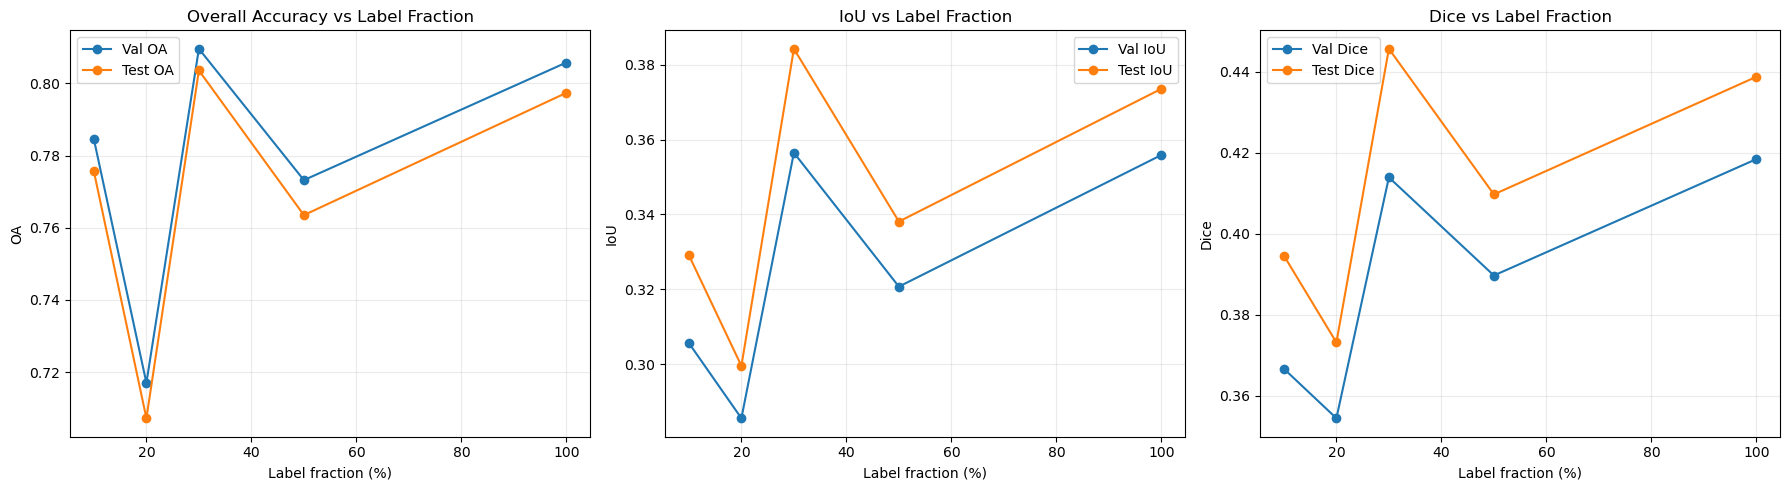

In [26]:
# ----------------------- plots (OA / IoU / Dice) -----------------------
def _ylims(*series, floor=0.0, ceil=1.0, pad=0.05):
    vals = np.concatenate([np.asarray(s, float)[~np.isnan(s)] for s in series if s is not None])
    if vals.size == 0:
        return (floor, ceil)
    lo, hi = float(vals.min()), float(vals.max())
    span = max(1e-6, hi - lo)
    return (max(floor, lo - pad*span), min(ceil, hi + pad*span))

plt.figure(figsize=(18,5))

# OA
ax1 = plt.subplot(1,3,1)
ax1.plot(df_unet["fraction_pct"], df_unet["val_OA"],  "o-", label="Val OA")
ax1.plot(df_unet["fraction_pct"], df_unet["test_OA"], "o-", label="Test OA")
ax1.set_title("Overall Accuracy vs Label Fraction")
ax1.set_xlabel("Label fraction (%)"); ax1.set_ylabel("OA")
ax1.set_ylim(*_ylims(df_unet["val_OA"], df_unet["test_OA"], floor=0.6, ceil=1.0))
ax1.grid(True, alpha=0.25); ax1.legend()

# IoU
ax2 = plt.subplot(1,3,2)
ax2.plot(df_unet["fraction_pct"], df_unet["val_IoU"],  "o-", label="Val IoU")
ax2.plot(df_unet["fraction_pct"], df_unet["test_IoU"], "o-", label="Test IoU")
ax2.set_title("IoU vs Label Fraction")
ax2.set_xlabel("Label fraction (%)"); ax2.set_ylabel("IoU")
ax2.set_ylim(*_ylims(df_unet["val_IoU"], df_unet["test_IoU"], floor=0.2, ceil=1.0))
ax2.grid(True, alpha=0.25); ax2.legend()

# Dice
ax3 = plt.subplot(1,3,3)
ax3.plot(df_unet["fraction_pct"], df_unet["val_Dice"],  "o-", label="Val Dice")
ax3.plot(df_unet["fraction_pct"], df_unet["test_Dice"], "o-", label="Test Dice")
ax3.set_title("Dice vs Label Fraction")
ax3.set_xlabel("Label fraction (%)"); ax3.set_ylabel("Dice")
ax3.set_ylim(*_ylims(df_unet["val_Dice"], df_unet["test_Dice"], floor=0.2, ceil=1.0))
ax3.grid(True, alpha=0.25); ax3.legend()

plt.tight_layout(); plt.show()